# Block 19 — Time Series: RNNs
### Advanced Machine Learning — M&T Bank

**Dataset:** `macro_vix_monthly.csv` (unchanged since Block 17). Same chronological split. No new CSV comes out
of this block.

Block 18's residual diagnostics found real, leftover structure in ARIMA(1,0,0)'s errors — consistent with
*volatility clustering*, a nonlinear pattern a linear AR term can't reach. This block builds a Recurrent Neural
Network **from scratch in numpy** (no deep-learning framework — same device as Block 4's gradient descent) to see
whether a model that can learn nonlinear, state-dependent dynamics does any better.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for macro_vix_monthly.csv below, then remove the leading '#':
# vix = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";", parse_dates=["date"]).set_index("date")
series = vix["vix_close"].values
dates = vix.index
n = len(series)
split_idx = int(n * 0.8)
print(f"{n} months total. Train/test split at index {split_idx} (same chronological split as Blocks 17-18).")


## 1. Preparing Sequences

An RNN needs fixed-length input windows, not single rows: given the last `L` months, predict the next one.
**Scaling has to be fit on train only** — the same leakage-safe-scaling discipline from Block 2/9, generalized
here to a sequence model instead of a single-row feature.


In [2]:
L = 6  # window length: predict month t from months [t-L, ..., t-1]

train_raw = series[:split_idx]
mu, sigma = train_raw.mean(), train_raw.std()  # fit on train only
scaled = (series - mu) / sigma

X, y, target_idx = [], [], []
for t in range(L, n):
    X.append(scaled[t - L:t])
    y.append(scaled[t])
    target_idx.append(t)
X, y, target_idx = np.array(X), np.array(y), np.array(target_idx)

train_mask = target_idx < split_idx
test_mask = target_idx >= split_idx
Xtr, ytr = X[train_mask], y[train_mask]
Xte, yte = X[test_mask], y[test_mask]
print(f"Train windows: {len(Xtr)}. Test windows: {len(Xte)} (matches Block 17/18's 88-month test set).")


Train windows: 345. Test windows: 88 (matches Block 17/18's 88-month test set).


## 2. The RNN, Built From Scratch

A single hidden layer, run one time-step at a time: `h_t = tanh(Wxh * x_t + Whh @ h_{t-1} + bh)`. After the last
step, a linear readout produces the forecast: `y_hat = Why @ h_L + by`. The hidden vector `h_t` is the model's
running summary of everything it's seen in the window so far — its "state."


In [3]:
rng = np.random.RandomState(0)
hidden = 8
Wxh = rng.randn(hidden, 1) * 0.3
Whh = rng.randn(hidden, hidden) * 0.3
Why = rng.randn(1, hidden) * 0.3
bh = np.zeros((hidden, 1))
by = np.zeros((1, 1))

def forward(x_seq):
    h = np.zeros((hidden, 1))
    hs = [h]
    for x in x_seq:
        h = np.tanh(Wxh * x + Whh @ h + bh)
        hs.append(h)
    y_hat = (Why @ h + by).item()
    return y_hat, hs


### Backpropagation Through Time

The same gradient-descent idea as Block 4, applied step by step backward through the sequence: the error at the
output flows back through the final hidden state, and then back through every earlier time step in turn,
accumulating gradients for the *same* shared weight matrices at each step.


In [4]:
def backward(x_seq, hs, y_hat, y_true, lr):
    global Wxh, Whh, Why, bh, by
    dy = y_hat - y_true                      # d(0.5*(y_hat-y_true)^2)/dy_hat
    dWhy = dy * hs[-1].T
    dby = np.array([[dy]])
    dh_next = Why.T * dy                     # gradient flowing into the last hidden state

    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dbh = np.zeros_like(bh)
    for t in reversed(range(len(x_seq))):
        h, h_prev = hs[t + 1], hs[t]
        dtanh = (1 - h ** 2) * dh_next       # tanh derivative
        dWxh += dtanh * x_seq[t]
        dWhh += dtanh @ h_prev.T
        dbh += dtanh
        dh_next = Whh.T @ dtanh              # carry gradient back one more time step

    Wxh -= lr * dWxh; Whh -= lr * dWhh; Why -= lr * dWhy
    bh -= lr * dbh; by -= lr * dby


## 3. Training

Plain stochastic gradient descent, one sequence at a time, shuffled each epoch — the same optimizer as Block 4,
just with gradients that now have to travel back through six time steps instead of none.


In [5]:
lr, epochs = 0.02, 60
n_train = len(Xtr)
loss_history = []

for ep in range(epochs):
    order = rng.permutation(n_train)
    total_loss = 0.0
    for i in order:
        y_hat, hs = forward(Xtr[i])
        total_loss += 0.5 * (y_hat - ytr[i]) ** 2
        backward(Xtr[i], hs, y_hat, ytr[i], lr)
    loss_history.append(total_loss / n_train)
    if ep % 10 == 0 or ep == epochs - 1:
        print(f"epoch {ep:2d}: avg train loss {loss_history[-1]:.5f}")


epoch  0: avg train loss 0.19765


epoch 10: avg train loss 0.11558


epoch 20: avg train loss 0.11615


epoch 30: avg train loss 0.11196


epoch 40: avg train loss 0.11107


epoch 50: avg train loss 0.10532
epoch 59: avg train loss 0.10264


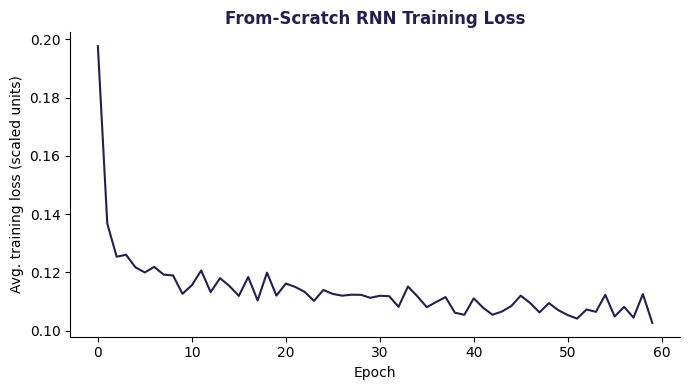

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history, color=NAVY)
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg. training loss (scaled units)")
ax.set_title("From-Scratch RNN Training Loss", color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("block19_loss_curve.png", dpi=110)
plt.show()


## 4. Does It Beat ARIMA?

Every test-window forecast here uses only real historical values (not the model's own prior predictions) — the
same one-step-ahead discipline as Block 18's walk-forward evaluation, so this is a fair comparison.


In [7]:
preds_scaled = np.array([forward(x)[0] for x in Xte])
preds = preds_scaled * sigma + mu
actual = yte * sigma + mu

rnn_mae = np.mean(np.abs(actual - preds))
rnn_rmse = np.sqrt(np.mean((actual - preds) ** 2))

comparison = pd.DataFrame([
    ["Naive (Block 17)", 3.192, 5.600],
    ["Lag-1 regression (Block 17)", 2.996, 5.326],
    ["ARIMA(1,0,0), static forecast (Block 18)", 4.485, 6.887],
    ["ARIMA(1,0,0), walk-forward (Block 18)", 2.986, 5.303],
    ["RNN, from scratch (this block)", round(rnn_mae, 3), round(rnn_rmse, 3)],
], columns=["Model", "MAE", "RMSE"])
comparison


,Model,MAE,RMSE
0,Naive (Block 17),3.192,5.600
1,Lag-1 regression (Block 17),2.996,5.326
2,"ARIMA(1,0,0), static forecast (Block 18)",4.485,6.887
3,"ARIMA(1,0,0), walk-forward (Block 18)",2.986,5.303
4,"RNN, from scratch (this block)",3.041,5.449


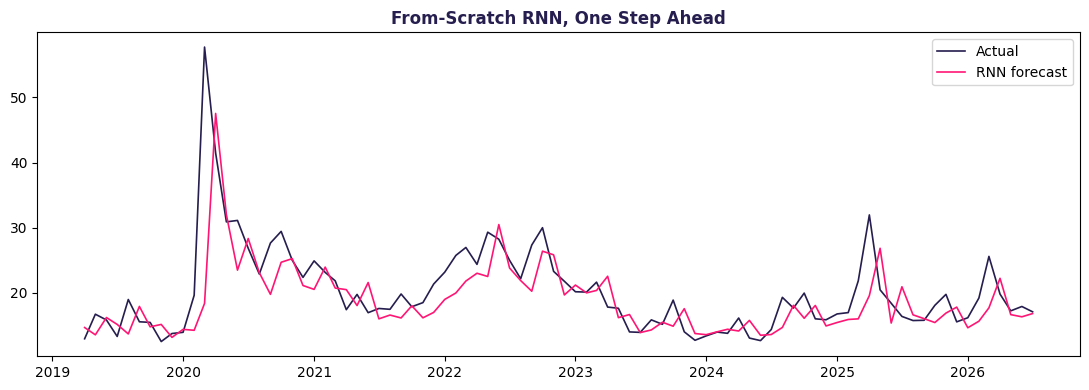

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
test_dates = dates[target_idx[test_mask]]
ax.plot(test_dates, actual, label="Actual", color=NAVY, linewidth=1.2)
ax.plot(test_dates, preds, label="RNN forecast", color=PINK, linewidth=1.2)
ax.legend()
ax.set_title("From-Scratch RNN, One Step Ahead", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.savefig("block19_rnn_forecast.png", dpi=110)
plt.show()


**The RNN clearly beats ARIMA's static forecast and lands in the same neighborhood as the naive baseline and
ARIMA's walk-forward result — but it doesn't beat the simpler linear models here.** That's an honest result worth
sitting with, not a disappointing one: this is 439 months of data and a 6-step window — a small dataset by deep
learning standards, and RNNs need volume to learn nonlinear dynamics that a hand-built AR(1) term, with three
parameters, doesn't need volume for at all. The same "complexity is a cost" discipline as Block 12's Random
Forest: more capacity has to earn its keep with more data to back it up, and here there isn't enough.


## 5. What Is the Hidden State Actually Encoding?

The RNN's hidden vector at each window's final step is an 8-number summary of the last six months. Reduce it to
its dominant direction of variation (PCA) and check whether that direction tracks anything real.


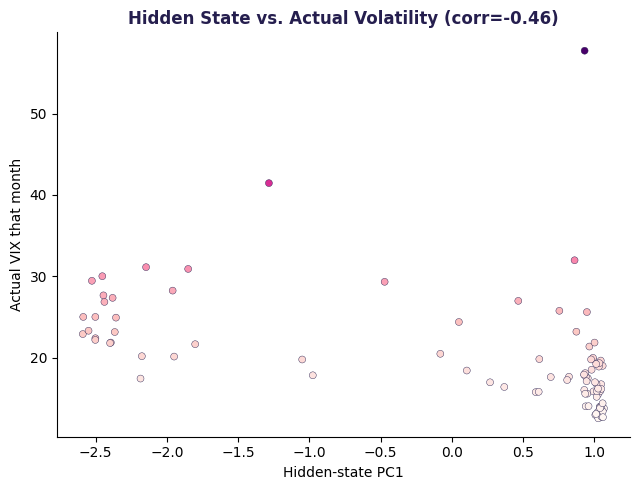

PC1 explains 91.2% of hidden-state variance; corr(PC1, actual VIX) = -0.463


In [9]:
H = np.array([forward(x)[1][-1].flatten() for x in Xte])
Hc = H - H.mean(axis=0)
U, S, Vt = np.linalg.svd(Hc, full_matrices=False)
pc1 = U[:, 0] * S[0]
explained = (S ** 2 / np.sum(S ** 2))[0]
corr = np.corrcoef(pc1, actual)[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(pc1, actual, c=actual, cmap="RdPu", s=25, edgecolor=NAVY, linewidth=0.3)
ax.set_xlabel("Hidden-state PC1")
ax.set_ylabel("Actual VIX that month")
ax.set_title(f"Hidden State vs. Actual Volatility (corr={corr:.2f})", color=NAVY, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("block19_hidden_state.png", dpi=110)
plt.show()

print(f"PC1 explains {explained:.1%} of hidden-state variance; corr(PC1, actual VIX) = {corr:.3f}")


**A single direction through the 8-dimensional hidden state explains over 90% of its variation, and that
direction correlates moderately (-0.46) with the actual volatility level the model is trying to predict.** No one
told the network to build a "volatility regime" indicator — it emerged from training on the forecasting task
alone, the same way Block 15's item-item similarity emerged with no one telling it "mortgage customers like
HELOCs." Nothing here is guaranteed to be interpretable or clean, and it isn't perfectly clean (a -0.46
correlation leaves plenty unexplained) — but there is a real, checkable signal in what the state learned, not
just an assumption that it should be there.


## Recap: Three Models, Three Answers

| Model | Best result (RMSE) | What it's good at |
|---|---|---|
| Naive / lag-1 regression | 5.33-5.60 | Dead simple, no training, hard baseline to beat |
| ARIMA(1,0,0) | 5.30 (walk-forward) | Matches the process's real linear structure exactly, with 3 parameters |
| RNN (from scratch) | 5.45 | Can in principle learn nonlinear dynamics — needs more data than this series has to prove it |

**Three blocks, one throughline:** partition chronologically, evaluate the way the model will actually be used,
and let the data — not the model's sophistication — decide what wins. The winner here was the simplest model in
the room, and that's a legitimate, reportable finding for any production recommendation.


**Next: Block 20** — wrapping up the full two-day course.
